In [ ]:
# ==========================================================
# STEP 1: IMPORT LIBRARIES
# ==========================================================
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [ ]:
# ==========================================================
# STEP 2: DATASET PATH
# ==========================================================
data_dir = r"C:\Users\zaina\Downloads\AI DISEASE PREDICTION\Dataset_BUSI_with_GT"

categories = ['benign', 'malignant', 'normal']
img_size = 128

In [ ]:
# ==========================================================
# STEP 3: LOAD + PREPROCESS IMAGES
# ==========================================================
data = []
labels = []

for category in categories:
    folder_path = os.path.join(data_dir, category)
    label = categories.index(category)

    for file in os.listdir(folder_path):

        # VERY IMPORTANT → skip mask images
        if "_mask" in file:
            continue

        if file.endswith(".png"):
            img_path = os.path.join(folder_path, file)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (img_size, img_size))

            # Improve contrast
            img = cv2.equalizeHist(img)

            # Normalize
            img = img / 255.0

            # Flatten
            img = img.flatten()

            data.append(img)
            labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Total images loaded:", len(data))

Total images loaded: 1256


In [ ]:
# ==========================================================
# STEP 4: TRAIN TEST SPLIT
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1004
Testing samples: 252


In [ ]:
# ==========================================================
# STEP 5: TRAIN RANDOM FOREST
# ==========================================================
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
# ==========================================================
# STEP 6: EVALUATION
# ==========================================================
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {acc*100:.2f}%")

print(classification_report(
    y_test,
    y_pred,
    target_names=categories
))

Model Accuracy: 94.05%
              precision    recall  f1-score   support

      benign       0.92      0.91      0.91        88
   malignant       0.93      0.95      0.94        84
      normal       0.97      0.96      0.97        80

    accuracy                           0.94       252
   macro avg       0.94      0.94      0.94       252
weighted avg       0.94      0.94      0.94       252



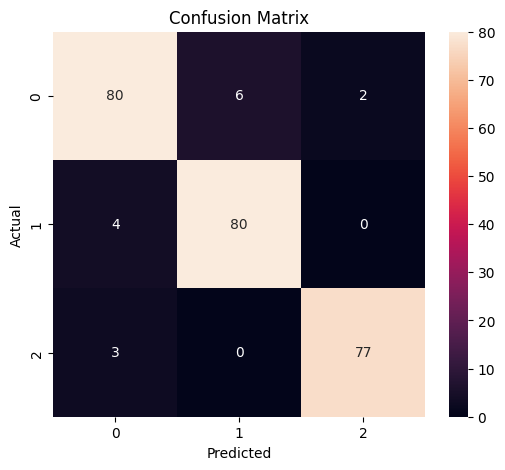

In [ ]:
# ==========================================================
# STEP 7: CONFUSION MATRIX
# ==========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

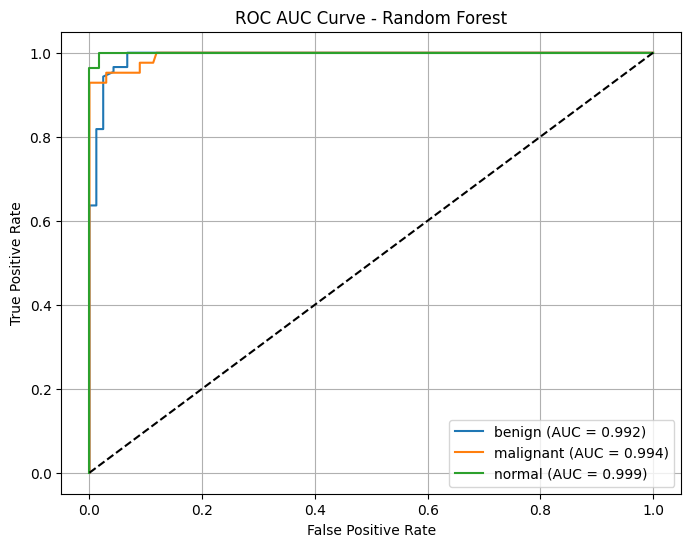

In [ ]:
# ==========================================================
# STEP 8: ROC AUC CURVE
# ==========================================================
y_prob = rf_model.predict_proba(X_test)

n_classes = len(categories)

y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{categories[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

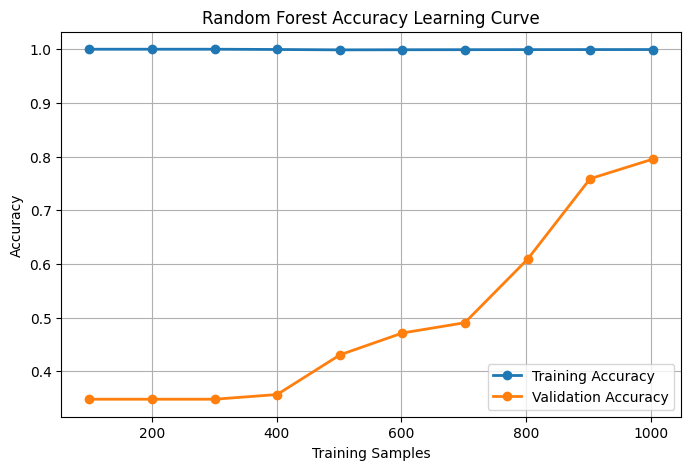

In [ ]:
# ==========================================================
# STEP 9: RANDOM FOREST ACCURACY LEARNING CURVE
# ==========================================================
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    rf_model,
    data,
    labels,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_mean,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title("Random Forest Accuracy Learning Curve")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

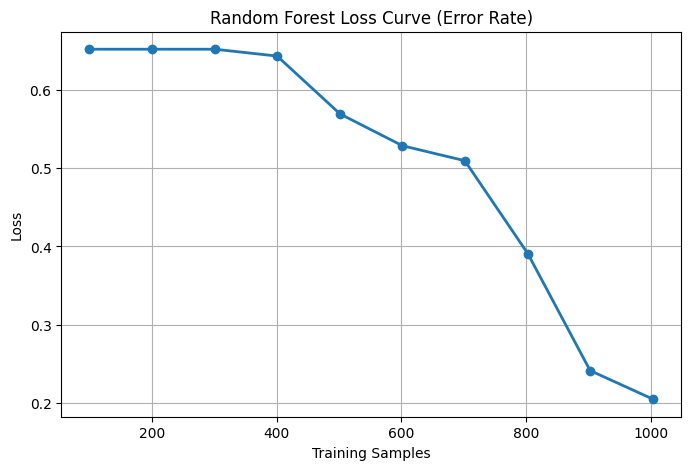

In [ ]:
# ==========================================================
# STEP 10: RANDOM FOREST LOSS CURVE (ERROR RATE)
# ==========================================================
error_curve = 1 - test_mean

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    error_curve,
    marker='o',
    linewidth=2
)

plt.title("Random Forest Loss Curve (Error Rate)")
plt.xlabel("Training Samples")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

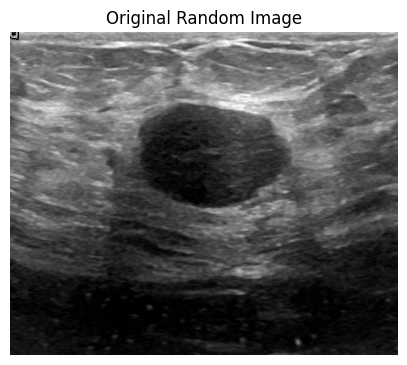

Actual Class: benign
Predicted Class: benign


In [ ]:
# ==========================================================
# STEP 11: RANDOM IMAGE PREDICTION
# ==========================================================
random_category = random.choice(categories)

folder_path = os.path.join(data_dir, random_category)

valid_images = [
    file for file in os.listdir(folder_path)
    if file.endswith(".png") and "_mask" not in file
]

random_image = random.choice(valid_images)

img_path = os.path.join(folder_path, random_image)

original_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,5))
plt.imshow(original_img, cmap='gray')
plt.title("Original Random Image")
plt.axis("off")
plt.show()

img = cv2.resize(original_img, (img_size, img_size))
img = cv2.equalizeHist(img)
img = img / 255.0
img = img.flatten().reshape(1, -1)

prediction = rf_model.predict(img)[0]

print("Actual Class:", random_category)
print("Predicted Class:", categories[prediction])

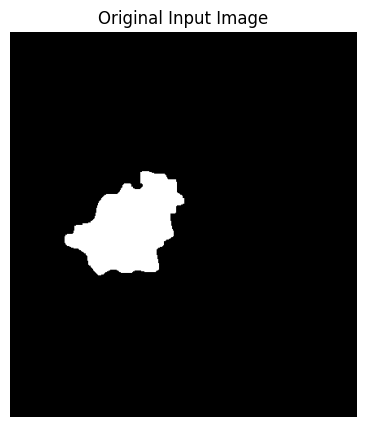

Predicted Class: benign


In [ ]:
# ==========================================================
# STEP 12: USER INPUT IMAGE PREDICTION
# ==========================================================
user_img_path = input("Enter full image path: ")

user_img = cv2.imread(user_img_path, cv2.IMREAD_GRAYSCALE)

if user_img is None:
    print("Invalid image path.")
else:
    plt.figure(figsize=(5,5))
    plt.imshow(user_img, cmap='gray')
    plt.title("Original Input Image")
    plt.axis("off")
    plt.show()

    img = cv2.resize(user_img, (img_size, img_size))
    img = cv2.equalizeHist(img)
    img = img / 255.0
    img = img.flatten().reshape(1, -1)

    prediction = rf_model.predict(img)[0]

    print("Predicted Class:", categories[prediction])

In [ ]:
import pickle
import os

os.makedirs("model", exist_ok=True)

with open("model/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print(" Random Forest model saved as model/random_forest_model.pkl")


 Random Forest model saved as model/random_forest_model.pkl
